In [115]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df=pd.read_csv("C:\\Users\\dhruv\\Downloads\\Housing.csv")

In [148]:
# Data exploration and cleaning
def explore_and_clean_data(df):
    print("=== Step 2: Exploring and cleaning the data ===")
    
    # Validate input
    if df is None:
        print("Error: Input DataFrame is None. Cannot proceed with cleaning.")
        return None
    if df.empty:
        print("Error: Input DataFrame is empty. Cannot proceed with cleaning.")
        return None
    
    # Check basic info and missing values
    print("Dataset Info:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    # Define categorical columns
    categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                          'airconditioning', 'prefarea', 'furnishingstatus']
    
    # Validate that all expected columns exist
    missing_columns = [col for col in categorical_columns if col not in df.columns]
    if missing_columns:
        print(f"Error: The following expected columns are missing in the dataset: {missing_columns}")
        return None
    
    # Debug: Check data types and unique values in each categorical column
    print("\nData types of categorical columns:")
    for col in categorical_columns:
        print(f"{col}: {df[col].dtype}")
    
    print("\nUnique values in categorical columns before mapping:")
    for col in categorical_columns:
        print(f"{col}: {df[col].unique()}")
    
    # Converting yes/no columns to binary
    yes_no_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
    for col in yes_no_columns:
        try:
            # Ensure the column is treated as a string, handle non-string types
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].map({'yes': 1, 'no': 0})
            # Handle any unmapped values (e.g., unexpected values become NaN)
            unmapped_values = df[col].isna().sum()
            if unmapped_values > 0:
                print(f"Warning: {unmapped_values} unmapped values in column '{col}' after mapping. Filling with 0.")
            df[col] = df[col].fillna(0).astype(int)
        except Exception as e:
            print(f"Error while processing column '{col}': {str(e)}")
            return None
    
    # Converting furnishingstatus to numerical
    try:
        df['furnishingstatus'] = df['furnishingstatus'].astype(str).str.lower().str.strip()
        df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})
        unmapped_values = df['furnishingstatus'].isna().sum()
        if unmapped_values > 0:
            print(f"Warning: {unmapped_values} unmapped values in column 'furnishingstatus' after mapping. Filling with 0.")
        df['furnishingstatus'] = df['furnishingstatus'].fillna(0).astype(int)
    except Exception as e:
        print(f"Error while processing column 'furnishingstatus': {str(e)}")
        return None
    
    # Final check for NaN values
    print("\nChecking for NaN values after mapping:")
    print(df.isnull().sum())
    
    print("\nData cleaning completed. Sample of cleaned data:")
    print(df.head())
    print(f"Updated shape after cleaning: {df.shape}")
    return df

# Execute the section (assumes df is available from Section 1)
if 'df' in globals() and df is not None:
    df_cleaned = explore_and_clean_data(df)
else:
    print("Cannot proceed: Dataset not loaded. Ensure Section 1 (Load Data) was executed successfully.")

=== Step 2: Exploring and cleaning the data ===
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int32
 6   guestroom         545 non-null    int32
 7   basement          545 non-null    int32
 8   hotwaterheating   545 non-null    int32
 9   airconditioning   545 non-null    int32
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int32
 12  furnishingstatus  545 non-null    int32
dtypes: int32(7), int64(6)
memory usage: 40.6 KB
None

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0

In [165]:
# Feature selection
def select_features(df):
    
    # Selecting features based on correlation with price
    correlation_matrix = df.corr()
    print("\nCorrelation with Price:")
    print(correlation_matrix['price'].sort_values(ascending=False))
    
    # Selecting features with reasonable correlation
    features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 
                'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 
                'parking', 'prefarea', 'furnishingstatus']
    
    X = df[features]
    y = df['price']
    
    print(f"Selected features shape: {X.shape}, Target shape: {y.shape}")
    return X, y

# Execute the section (assumes df_cleaned is available from Section 2)
if 'df_cleaned' in globals() and df_cleaned is not None:
    X, y = select_features(df_cleaned)
else:
    print("Cannot proceed: Cleaned dataset not available.")


Correlation with Price:
price               1.000000
area                0.535997
bathrooms           0.517545
stories             0.420712
parking             0.384394
bedrooms            0.366494
mainroad                 NaN
guestroom                NaN
basement                 NaN
hotwaterheating          NaN
airconditioning          NaN
prefarea                 NaN
furnishingstatus         NaN
Name: price, dtype: float64
Selected features shape: (545, 12), Target shape: (545,)


In [152]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model training and evaluation
def train_and_evaluate_model(X, y):
    print("=== Step 4: Training and evaluating the model ===")
    # Input validation
    if X is None or y is None:
        print("Error: X or y is None. Cannot proceed with training.")
        return None, None, None, None, None
    if X.shape[0] != y.shape[0]:
        print(f"Error: Mismatch in shapes - X: {X.shape}, y: {y.shape}")
        return None, None, None, None, None
    if np.any(np.isnan(X)) or np.any(np.isnan(y)):
        print("Error: NaN values detected in features or target. Cleaning required.")
        return None, None, None, None, None
    
    # Splitting the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
    
    # Scaling features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Training the model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Making predictions
    y_pred = model.predict(X_test_scaled)
    
    # Evaluating the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\nModel Performance:")
    print(f"Mean Squared Error: {mse:,.2f}")
    print(f"R-squared Score: {r2:.4f}")
    print("Model training and evaluation completed.")
    return model, X_test_scaled, y_test, y_pred, scaler

# Execute the section (assumes X and y are available from Section 3)
print("Checking availability of X and y...")
if 'X' in globals() and 'y' in globals() and X is not None and y is not None:
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    print("Sample of X:")
    print(X.head() if hasattr(X, 'head') else X[:5])
    print("Sample of y:")
    print(y.head() if hasattr(y, 'head') else y[:5])
    model, X_test_scaled, y_test, y_pred, scaler = train_and_evaluate_model(X, y)
else:
    print("Cannot proceed: Features and target not available.")
    print("Ensure Section 3 (Feature Selection) was executed successfully.")

Checking availability of X and y...
X shape: (545, 12), y shape: (545,)
Sample of X:
   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         0          0         0   
1  8960         4          4        4         0          0         0   
2  9960         3          2        2         0          0         0   
3  7500         4          2        2         0          0         0   
4  7420         4          1        2         0          0         0   

   hotwaterheating  airconditioning  parking  prefarea  furnishingstatus  
0                0                0        2         0                 0  
1                0                0        3         0                 0  
2                0                0        2         0                 0  
3                0                0        3         0                 0  
4                0                0        2         0                 0  
Sample of y:
0    13300000
1    

=== Step 5: Generating visualizations ===
Saved: actual_vs_predicted.png
Saved: feature_importance.png
Saved: cleaned_housing_data.csv


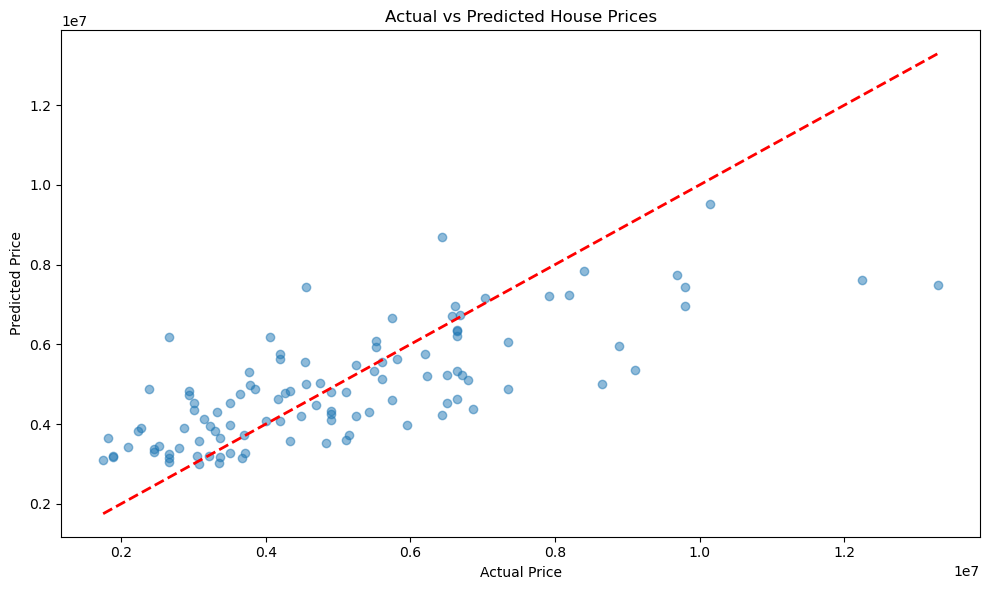

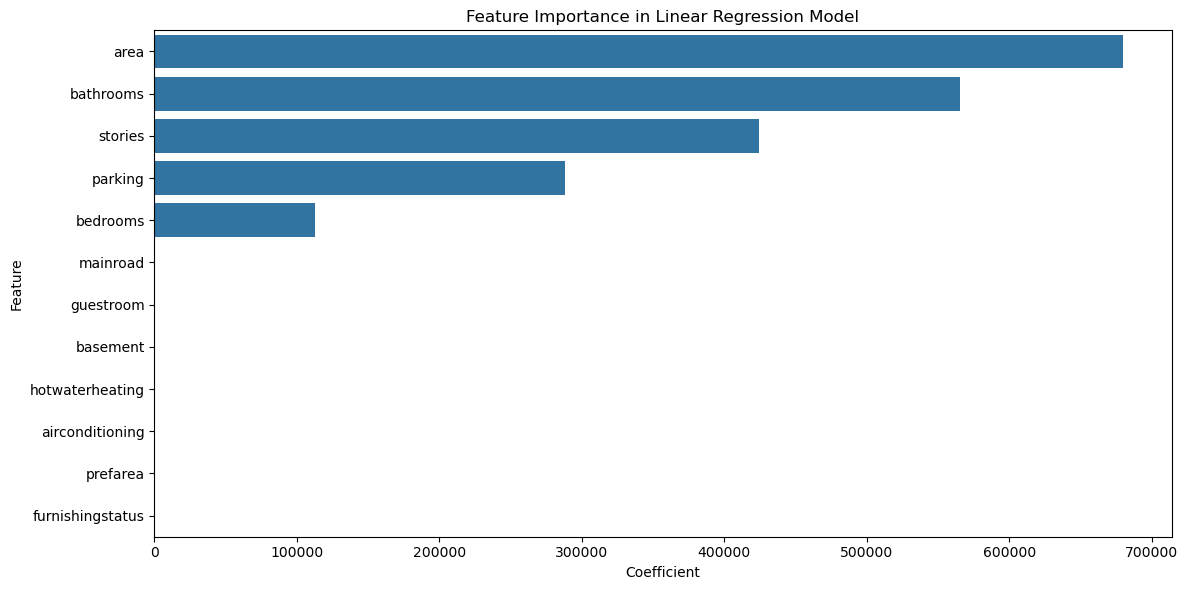

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization
def visualize_results(y_test, y_pred, X_test_scaled, model, scaler):
    print("=== Step 5: Generating visualizations ===")
    # Creating a scatter plot of actual vs predicted prices
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted House Prices')
    plt.tight_layout()
    plt.savefig('actual_vs_predicted.png')
    print("Saved: actual_vs_predicted.png")
    
    # Creating a feature importance plot
    feature_names = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 
                    'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 
                    'parking', 'prefarea', 'furnishingstatus']
    
    coefficients = model.coef_
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    }).sort_values(by='Coefficient', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
    plt.title('Feature Importance in Linear Regression Model')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    print("Saved: feature_importance.png")

# Saving the cleaned dataset and visualizing results
if all(var in globals() for var in ['y_test', 'y_pred', 'X_test_scaled', 'model', 'scaler', 'df_cleaned']):
    visualize_results(y_test, y_pred, X_test_scaled, model, scaler)
    df_cleaned.to_csv('cleaned_housing_data.csv', index=False)
    print("Saved: cleaned_housing_data.csv")
else:
    print("Cannot proceed: Required variables for visualization not available.")